# BikeFlow 2024 探索性数据分析（Exploratory Data Analysis, EDA）

BikeFlow 使用 2024 年纽约 Citi Bike 骑行记录与 Open-Meteo 历史天气，研究共享单车每小时的需求。原始记录中的 started_at 是骑行开始时间；汇总后的 ride_count 表示**在对应纽约本地小时内开始的骑行次数**。天气数据来自纽约附近的一个网格点。

本 Notebook 检查数据质量，并探索月度、星期、小时及天气对应的需求模式。本阶段只进行探索性数据分析（EDA），不训练机器学习模型，也不构造预测用的滞后特征。

## 内容速览

全年有 **44,302,799** 次有效骑行。EDA 使用 **8,783 个有效本地时钟小时标签**；全年实际经过 **8,784 个物理小时**，差异来自夏令时（DST）。10 月总骑行量最高，9 月平均每小时需求最高。总体高峰在 17:00；工作日 08:00 和 17:00 呈通勤双峰，周末高峰更集中于下午。降雨和降雪小时的观察需求较低，但季节和时段也会影响这些比较。


## 数据来源与分析口径（Sources and Methods）

### 数据来源与粒度（Grain）

- `data/processed/bikeflow_2024.csv`：由 2024 年 Citi Bike 有效 `started_at` 记录汇总而成。每行是一个**纽约本地时钟小时标签**；表中保留春季不存在的 02:00 占位行，并把秋季重复的两个 01:00 合并到一个标签。
- `data/raw/weather/open_meteo_nyc_2024.json`：保存的 Open-Meteo 历史天气响应，额外含 2025-01-01 00:00 本地时间点，以对齐 2024 年最后一个骑行小时。请求位置为北纬 40.7580°、西经 73.9855°；单个天气网格点不能代表全市每条街道。
- [Open-Meteo 历史天气文档](https://open-meteo.com/en/docs/historical-weather-api)说明：`precipitation`、`rain` 和 `snowfall` 是时间戳**前一小时**的累计值。当前响应中，前两者单位为 mm，降雪单位为 cm；温度为 °C、湿度为 %、风速为 km/h。其他天气字段表示其时间戳处的状态。

### 为什么需要聚合（Aggregation）

原始 Citi Bike 数据中，**一行 = 一次骑行（ride）**；BikeFlow 的小时需求数据中，**一行 = 一个小时**。聚合（aggregation）就是按共同时间段分组，把细粒度记录汇总成更高层级的统计指标：

```text
44,302,799 次骑行
        ↓ 按 started_at 所在的纽约本地小时分组
计算每小时 ride_count
        ↓
8,784 个时钟小时标签（含春季不存在的 02:00 占位行）
        ↓ 去掉该占位行，仅用于 EDA
8,783 个有效标签
```

全年真实经过 8,784 个物理小时：秋季 01:00 出现两次，只是被合并到一个本地时钟标签。

### 关键口径（Key Assumptions）

- `ride_count[t]` 统计物理区间 `[t, t+1h)` 内开始的骑行。天气累计值标在区间的**结束时刻**；先按 UTC 物理时刻对齐，再转回纽约本地标签。秋季两个真实的 01:00 最终汇入已有的同一个需求标签。
- 原始 `precipitation`、`rain`、`snowfall` 列保留供核对；EDA 使用对齐后的 `*_during_hour` 列。Notebook 不重写原始 CSV。
- 春季不存在的 02:00 占位行只从 EDA 分析表移除。秋季合并的 01:00 保留，并标记 `dst_fallback_anomaly=True`；它包含两个物理小时，不能当成普通单小时解释。
- `day_of_week` 以周一为 0、周日为 6；`is_weekend` 表示周六或周日。图表展示描述性关联（descriptive association），不能单凭分组比较推断因果。


## 1. 数据概览（Data Overview）

先加载小时需求和天气数据，检查记录数、缺失值与全年骑行总数。这样能确认后续图表使用的是同一份分析数据，并及早发现时间或数据量异常。


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data" / "processed" / "bikeflow_2024.csv").exists() else Path.cwd().parent
if not (PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv").exists():
    raise FileNotFoundError("Run from the BikeFlow project root or notebooks directory")
sys.path.insert(0, str(PROJECT_ROOT))
from src.features.eda import (
    DAY_NAMES, WEATHER_COLUMNS, FALL_REPEAT, SPRING_GAP, prepare_eda_data,
)

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv"
RAW_WEATHER_PATH = PROJECT_ROOT / "data" / "raw" / "weather" / "open_meteo_nyc_2024.json"
RESULTS_DIR = PROJECT_ROOT / "results" / "eda"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (9, 4.8), "figure.dpi": 110, "savefig.dpi": 150,
    "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.grid": False,
})
BLUE, GOLD, ORANGE, DARK = "#255B8B", "#D7A23D", "#D97145", "#273746"

def save_show(fig, filename):
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / filename, bbox_inches="tight")
    display(fig)
    plt.close(fig)

source = pd.read_csv(PROCESSED_PATH, parse_dates=["timestamp"])
df = prepare_eda_data(PROCESSED_PATH, RAW_WEATHER_PATH)
print(f"Source rows: {len(source):,}; EDA rows: {len(df):,}; total rides: {df.ride_count.sum():,}")
print("Missing values in EDA frame:")
display(df.isna().sum().to_frame("missing_rows").T)
assert len(df) == 8783 and df.timestamp.is_unique
assert int(df.ride_count.sum()) == 44_302_799

Source rows: 8,784; EDA rows: 8,783; total rides: 44,302,799
Missing values in EDA frame:


,timestamp,ride_count,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m,...,snowfall_during_hour,physical_weather_hours,dst_fallback_anomaly,hour,day_of_week,day_name,month,month_name,date,is_weekend
missing_rows,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. 夏令时处理（Daylight Saving Time, DST）

### 春季跳时（Spring Forward）

2024-03-10 纽约开始夏令时，时钟从 01:59 直接跳到 03:00，因此**本地时间 2024-03-10 02:00 并不存在**。源表为了保持连续的时钟标签，仍保留一行 `ride_count=0`、天气字段缺失的 02:00 占位记录。下面查看该行及前后小时；EDA 会排除它，但不会填造天气值，也不会把它当成真实的零需求小时。


In [2]:
audit_columns = ["timestamp", "ride_count", *WEATHER_COLUMNS]
spring_window = source.loc[source.timestamp.between("2024-03-10 00:00", "2024-03-10 04:00"), audit_columns]
display(spring_window)
assert len(spring_window) == 5
assert source.loc[source.timestamp.eq(SPRING_GAP), "ride_count"].item() == 0
assert source.loc[source.timestamp.eq(SPRING_GAP), WEATHER_COLUMNS].isna().all().all()
assert not df.timestamp.eq(SPRING_GAP).any()

,timestamp,ride_count,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m
1656,2024-03-10 00:00:00,666,8.0,4.9,98.0,2.6,2.6,0.0,63.0,16.9
1657,2024-03-10 01:00:00,695,8.9,7.0,97.0,0.0,0.0,0.0,3.0,9.9
1658,2024-03-10 02:00:00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1659,2024-03-10 03:00:00,582,8.8,7.0,97.0,0.0,0.0,0.0,3.0,9.3
1660,2024-03-10 04:00:00,404,7.0,3.7,98.0,0.1,0.1,0.0,51.0,16.6


### 秋季回拨（Fall Back）

2024-11-03 纽约结束夏令时，时钟从 01:59 回到 01:00，因此**本地时间 2024-11-03 01:00 出现两次**，对应两个物理小时。Citi Bike 原始 `started_at` 没有时区信息；按本地时钟小时聚合后，两次 01:00 的骑行被合并到一个 `ride_count` 标签。下面用邻近周日核对这个较大的计数，但不把它拆成两个无法可靠区分的值。

这也是小时聚合的关键：春季占位标签要从 EDA 排除，秋季合并标签要保留并标记。源表的秋季瞬时天气是两个物理观测的汇总值，累计天气则求和；本 Notebook 使用的区间累计天气会从 UTC 物理观测重新对齐。


In [3]:
fall_window = source.loc[source.timestamp.between("2024-11-03 00:00", "2024-11-03 04:00"), audit_columns]
display(fall_window)
neighbor_sundays = pd.date_range("2024-10-06", "2024-12-01", freq="W-SUN")
neighbor_sundays = neighbor_sundays[neighbor_sundays != pd.Timestamp("2024-11-03")]
sunday_hours = df.loc[df.timestamp.dt.normalize().isin(neighbor_sundays) & df.hour.isin([0, 1, 2, 3])]
sunday_comparison = sunday_hours.pivot(index="date", columns="hour", values="ride_count")
sunday_comparison["01 / 00"] = sunday_comparison[1] / sunday_comparison[0]
sunday_comparison["01 / 02"] = sunday_comparison[1] / sunday_comparison[2]
display(sunday_comparison.round(2))
fall_counts = df.loc[df.timestamp.between("2024-11-03 00:00", "2024-11-03 03:00")].set_index("hour").ride_count
print(f"Fall 01:00={fall_counts[1]:,}; nearby Sunday 01:00 median={sunday_comparison[1].median():,.1f}; "
      f"range={sunday_comparison[1].min():,} to {sunday_comparison[1].max():,}")
print(f"Fall 01/00={fall_counts[1]/fall_counts[0]:.2f}; fall 01/02={fall_counts[1]/fall_counts[2]:.2f}")
assert df.loc[df.timestamp.eq(FALL_REPEAT), "dst_fallback_anomaly"].item()
assert df.loc[df.timestamp.eq(FALL_REPEAT), "physical_weather_hours"].item() == 2

,timestamp,ride_count,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m
7368,2024-11-03 00:00:00,3010,6.50,2.50,58.0,0.0,0.0,0.0,0.0,11.4
7369,2024-11-03 01:00:00,3534,5.45,1.55,63.0,0.0,0.0,0.0,0.0,11.3
7370,2024-11-03 02:00:00,948,4.50,0.40,68.0,0.0,0.0,0.0,0.0,12.6
7371,2024-11-03 03:00:00,580,4.00,-0.40,66.0,0.0,0.0,0.0,0.0,14.1
7372,2024-11-03 04:00:00,539,3.70,-1.00,64.0,0.0,0.0,0.0,0.0,14.7


hour,0,1,2,3,01 / 00,01 / 02
date,,,,,,
2024-10-06,4049,2947,1910,1174,0.73,1.54
2024-10-13,3675,2672,1933,1339,0.73,1.38
2024-10-20,4203,2754,1751,1165,0.66,1.57
2024-10-27,3493,2604,1869,1485,0.75,1.39
2024-11-10,2873,1852,1288,896,0.64,1.44
2024-11-17,2851,2315,1555,932,0.81,1.49
2024-11-24,2453,1833,1125,775,0.75,1.63
2024-12-01,1210,856,491,371,0.71,1.74


Fall 01:00=3,534; nearby Sunday 01:00 median=2,459.5; range=856 to 2,947
Fall 01/00=1.17; fall 01/02=3.73


## 降水的小时对齐（Precipitation Time Alignment）

这里最容易混淆的是时间戳含义：Open-Meteo 的 `precipitation[t]` 表示 **t 前一个小时的累计降水**，而 BikeFlow 的 `ride_count[t]` 表示 **`[t, t+1)` 期间开始的骑行**。要研究骑行发生的这个小时是否下雨，就要使用该区间**结束时刻**的天气累计值。

```text
ride_count@08:00  →  统计 08:00–09:00 开始的骑行
Open-Meteo precipitation@09:00  →  统计 08:00–09:00 的累计降水
因此 precipitation_during_hour@08:00 取 09:00 的累计降水
```

`rain_during_hour` 和 `snowfall_during_hour` 采用同样的对应方式，分别表示这个骑行小时内的雨量（mm）和降雪量（cm）；`precipitation_during_hour` 表示总降水（mm）。对齐时按 UTC 的真实先后顺序寻找下一个物理小时，不能简单把本地表格下移一行：春季 01:00 的下一个真实天气终点是 03:00；秋季合并的 01:00 骑行标签对应两个物理小时的累计值之和。2024 年最后一个 23:00 骑行小时还需要 2025-01-01 00:00 的天气终点。

下面抽查夏令时前后和跨年边界，确认对齐后的三列含义。


In [4]:
check_hours = [
    "2024-03-10 01:00", "2024-03-10 03:00",
    "2024-11-03 00:00", "2024-11-03 01:00", "2024-11-03 02:00",
    "2024-12-31 23:00",
]
alignment_columns = ["timestamp", "physical_weather_hours", "precipitation", "precipitation_during_hour",
                     "rain", "rain_during_hour", "snowfall", "snowfall_during_hour"]
display(df.loc[df.timestamp.isin(pd.to_datetime(check_hours)), alignment_columns])
assert df.loc[df.timestamp.eq("2024-12-31 23:00"), "precipitation_during_hour"].item() == 0.9
assert df["physical_weather_hours"].value_counts().to_dict() == {1: 8782, 2: 1}

,timestamp,physical_weather_hours,precipitation,precipitation_during_hour,rain,rain_during_hour,snowfall,snowfall_during_hour
1657,2024-03-10 01:00:00,1,0.0,0.0,0.0,0.0,0.0,0.0
1658,2024-03-10 03:00:00,1,0.0,0.1,0.0,0.1,0.0,0.0
7367,2024-11-03 00:00:00,1,0.0,0.0,0.0,0.0,0.0,0.0
7368,2024-11-03 01:00:00,2,0.0,0.0,0.0,0.0,0.0,0.0
7369,2024-11-03 02:00:00,1,0.0,0.0,0.0,0.0,0.0,0.0
8782,2024-12-31 23:00:00,1,3.7,0.9,3.7,0.9,0.0,0.0


## 3. 时间特征（Time Features）

小时需求可以从不同时间尺度观察。`hour` 是一天中的小时，用来寻找早晚高峰；`day_of_week` 是星期几，用来比较一周内变化；`month` 是月份，用来观察季节性；`is_weekend` 区分工作日与周末，便于比较不同出行习惯。这些字段用于本次 EDA 的分组和解读。


### 全年概览与极端小时

先看 `ride_count` 的分布、全年总数及最高和最低的小时。这里的 8,783 是**有效本地时钟标签**数量；秋季 01:00 标签包含两个真实小时，所以按标签计算的平均值，与用全年 8,784 个物理小时计算的平均值略有不同。每日均值则以 366 个本地日历日为分母。


In [5]:
demand_stats = df.ride_count.describe(percentiles=[.25, .5, .75])
display(demand_stats.rename("ride_count").to_frame())
daily_totals = df.groupby("date").ride_count.sum()
overview = pd.Series({
    "Total rides": int(df.ride_count.sum()),
    "Real local-hour labels": len(df),
    "Real physical hours": int(df.physical_weather_hours.sum()),
    "Mean rides / local label": df.ride_count.mean(),
    "Mean rides / physical hour": df.ride_count.sum() / df.physical_weather_hours.sum(),
    "Mean rides / calendar day": daily_totals.mean(),
})
display(overview.to_frame("value"))
print("Top 10 demand labels:")
display(df.nlargest(10, "ride_count")[["timestamp", "day_name", "ride_count", "temperature_2m", "precipitation_during_hour", "dst_fallback_anomaly"]])
print("Bottom 10 real demand labels:")
display(df.nsmallest(10, "ride_count")[["timestamp", "day_name", "ride_count", "temperature_2m", "precipitation_during_hour", "dst_fallback_anomaly"]])

,ride_count
count,8783.000000
mean,5044.153364
std,4120.286122
min,50.000000
25%,1364.000000
50%,4236.000000
75%,7693.000000
max,19579.000000


,value
Total rides,4.430280e+07
Real local-hour labels,8.783000e+03
Real physical hours,8.784000e+03
Mean rides / local label,5.044153e+03
Mean rides / physical hour,5.043579e+03
Mean rides / calendar day,1.210459e+05


Top 10 demand labels:


,timestamp,day_name,ride_count,temperature_2m,precipitation_during_hour,dst_fallback_anomaly
7096,2024-10-22 17:00:00,Tuesday,19579,23.6,0.0,False
6088,2024-09-10 17:00:00,Tuesday,19545,24.6,0.0,False
6256,2024-09-17 17:00:00,Tuesday,19544,25.1,0.0,False
6280,2024-09-18 17:00:00,Wednesday,19434,22.4,0.0,False
7120,2024-10-23 17:00:00,Wednesday,19412,21.7,0.0,False
6304,2024-09-19 17:00:00,Thursday,19364,28.2,0.0,False
6136,2024-09-12 17:00:00,Thursday,19285,23.7,0.0,False
6112,2024-09-11 17:00:00,Wednesday,19257,23.4,0.0,False
6424,2024-09-24 17:00:00,Tuesday,19088,18.8,0.0,False
7288,2024-10-30 17:00:00,Wednesday,19028,23.5,0.0,False


Bottom 10 real demand labels:


,timestamp,day_name,ride_count,temperature_2m,precipitation_during_hour,dst_fallback_anomaly
1035,2024-02-13 03:00:00,Tuesday,50,0.5,2.1,False
363,2024-01-16 03:00:00,Tuesday,52,-4.7,0.3,False
411,2024-01-18 03:00:00,Thursday,61,-7.4,0.0,False
2258,2024-04-04 03:00:00,Thursday,62,3.7,1.2,False
387,2024-01-17 03:00:00,Wednesday,66,-8.4,0.0,False
2089,2024-03-28 02:00:00,Thursday,67,6.8,1.0,False
1036,2024-02-13 04:00:00,Tuesday,75,-0.2,1.9,False
149,2024-01-07 05:00:00,Sunday,78,1.6,0.1,False
8738,2024-12-30 03:00:00,Monday,80,11.7,0.1,False
675,2024-01-29 03:00:00,Monday,84,1.3,0.1,False


## 4. 月度需求趋势（Monthly Demand）

先看每月**总骑行量**，了解全年规模如何变化；再看每个有效小时标签的**平均需求**，减少月份天数不同造成的影响。两张图回答不同问题，不能把总量最高直接理解为每小时也最忙。3 月少一个真实的 02:00 时钟标签，但没有少一个物理小时；11 月的一个 01:00 标签合并了两个物理小时。


,month,month_name,total_rides,mean_hourly,samples
0,1,January,1887908,2537.510753,744
1,2,February,2121506,3048.140805,696
2,3,March,2663416,3584.678331,743
3,4,April,3216957,4467.995833,720
4,5,May,4135049,5557.861559,744
5,6,June,4782935,6642.965278,720
6,7,July,4722952,6348.053763,744
7,8,August,4603942,6188.094086,744
8,9,September,4997288,6940.677778,720
9,10,October,5150717,6923.006720,744


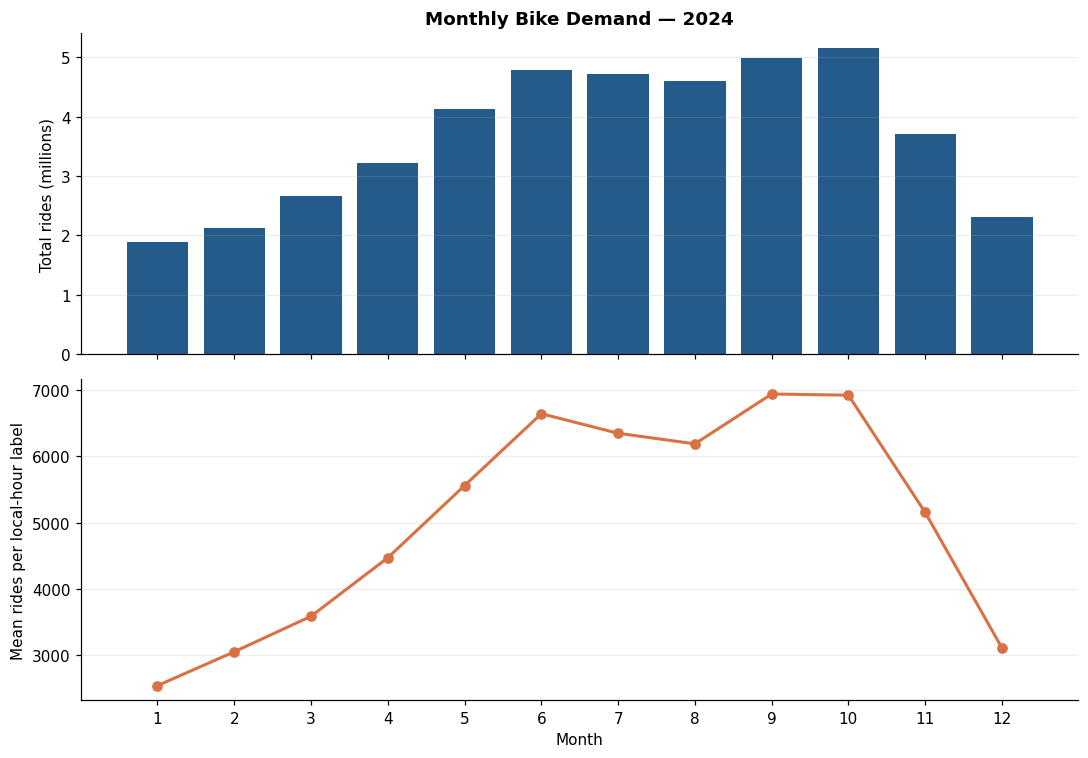

In [6]:
monthly = df.groupby(["month", "month_name"], sort=True).ride_count.agg(total_rides="sum", mean_hourly="mean", samples="size").reset_index()
display(monthly)
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].bar(monthly.month, monthly.total_rides / 1e6, color=BLUE)
axes[0].set(ylabel="Total rides (millions)", title="Monthly Bike Demand — 2024")
axes[1].plot(monthly.month, monthly.mean_hourly, color=ORANGE, marker="o", linewidth=2)
axes[1].set(xlabel="Month", ylabel="Mean rides per local-hour label", xticks=monthly.month)
for ax in axes: ax.grid(axis="y", alpha=.22)
save_show(fig, "monthly_demand.png")

**图后观察：**10 月总骑行量最高，为 5,150,717 次；1 月最低，为 1,887,908 次。按每个有效小时标签的平均需求比较，9 月约为 6,941 次，略高于 10 月的约 6,923 次。这说明“每月总量”和“每小时强度”的排名可以不同。


### 星期几的平均需求

这里先按 `day_of_week` 比较一周七天的平均需求，再汇总工作日和周末。`Monday=0`、`Sunday=6`；平均值以各组实际观测到的有效本地小时标签为分母。这样可以初步判断差异是否只来自某一天，不能马上把差异解释成天气或通勤的因果影响。


,day_of_week,day_name,mean_hourly,samples
0,0,Monday,4931.703616,1272
1,1,Tuesday,5271.954403,1272
2,2,Wednesday,5337.778045,1248
3,3,Thursday,5223.731571,1248
4,4,Friday,5272.307692,1248
5,5,Saturday,4840.803686,1248
6,6,Sunday,4428.082598,1247


,mean_hourly,median_hourly,samples
is_weekend,,,
Weekday,5206.688454,4566.5,6288
Weekend,4634.525852,3410.0,2495


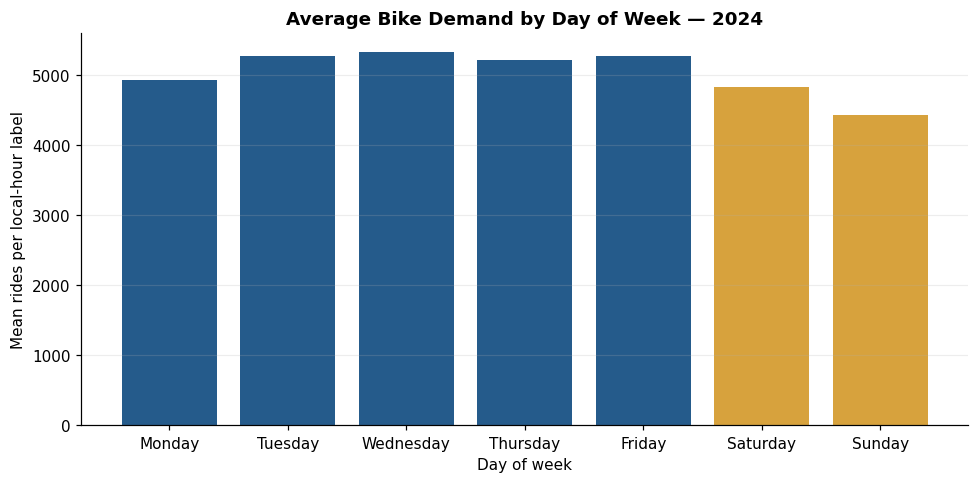

In [7]:
dow = df.groupby(["day_of_week", "day_name"], sort=True).ride_count.agg(mean_hourly="mean", samples="size").reset_index()
week_part = df.groupby("is_weekend").ride_count.agg(mean_hourly="mean", median_hourly="median", samples="size")
week_part.index = week_part.index.map({False: "Weekday", True: "Weekend"})
display(dow)
display(week_part)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(dow.day_name, dow.mean_hourly, color=[BLUE]*5 + [GOLD]*2)
ax.set(title="Average Bike Demand by Day of Week — 2024", ylabel="Mean rides per local-hour label", xlabel="Day of week")
ax.grid(axis="y", alpha=.22)
save_show(fig, "day_of_week_demand.png")

**图后观察：**工作日中，周三的平均需求最高，约为每标签 5,338 次；周日最低，约为 4,428 次。整体工作日均值为 5,207 次，高于周末的 4,635 次。下面再看差异发生在一天中的哪些时段。


## 5. 小时需求模式（Hourly Demand Pattern）

把所有日期按 `hour` 分组，可看出凌晨低谷、早高峰（morning peak）和晚高峰（evening peak）。这张总体曲线混合了工作日与周末，因此下一节会拆开比较。


,hour,mean_hourly,samples
0,0,1703.248634,366
1,1,1025.098361,366
2,2,658.358904,365
3,3,437.983607,366
4,4,395.128415,366
5,5,851.166667,366
6,6,2337.344262,366
7,7,4854.243169,366
8,8,7468.229508,366
9,9,6259.939891,366


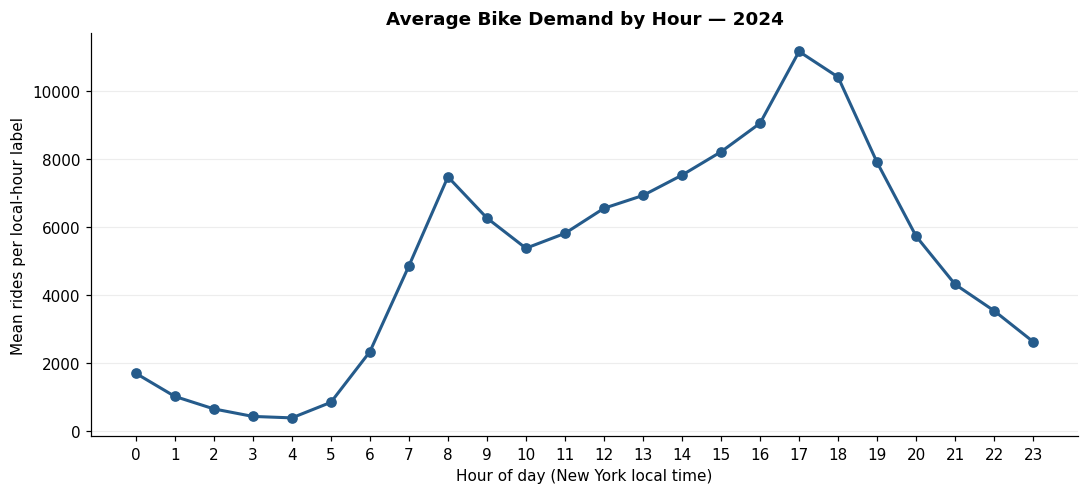

In [8]:
hourly = df.groupby("hour").ride_count.agg(mean_hourly="mean", samples="size").reset_index()
display(hourly)
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(hourly.hour, hourly.mean_hourly, marker="o", color=BLUE, linewidth=2)
ax.set(title="Average Bike Demand by Hour — 2024", xlabel="Hour of day (New York local time)",
       ylabel="Mean rides per local-hour label", xticks=range(24))
ax.grid(axis="y", alpha=.22)
save_show(fig, "hourly_pattern.png")

**图后观察：**总体平均需求最高的小时是 17:00，每标签约 11,147 次；04:00 最低，约 395 次。08:00 也有一个较小的上升。这个形状提示通勤行为，但还要分开看工作日和周末。


## 6. 工作日与周末（Weekday vs Weekend）

工作日和周末的出行目的与时间安排可能不同，把两组混在一起会掩盖各自的小时模式。下面比较两条曲线：是否有早晚通勤双峰（commuting double-peak pattern），以及周末需求是否移向下午。秋季合并的 01:00 标签仍保留在周末曲线中，并在数据表中单独标记。


day_type,Weekday,Weekend
hour,,
0,1342.7,2611.6
1,705.1,1831.3
2,425.4,1251.0
3,282.0,831.0
4,333.0,551.8
5,1007.5,457.3
6,2906.1,904.6
7,6114.6,1679.2
8,9298.4,2857.6


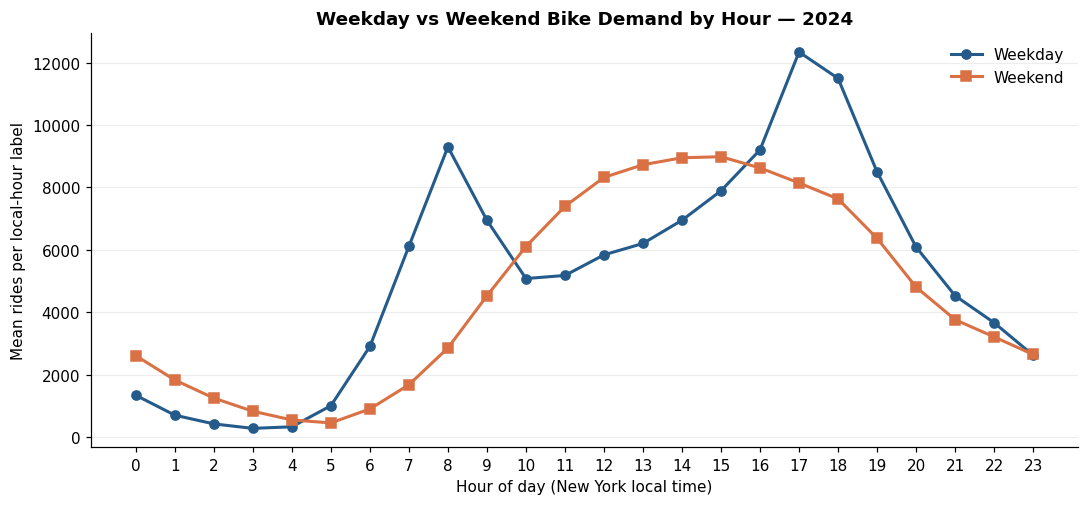

In [9]:
hour_by_part = df.groupby(["is_weekend", "hour"]).ride_count.agg(mean_hourly="mean", samples="size").reset_index()
hour_by_part["day_type"] = hour_by_part.is_weekend.map({False: "Weekday", True: "Weekend"})
hour_pivot = hour_by_part.pivot(index="hour", columns="day_type", values="mean_hourly")
display(hour_pivot.round(1))
fig, ax = plt.subplots(figsize=(10, 4.7))
ax.plot(hour_pivot.index, hour_pivot.Weekday, color=BLUE, marker="o", label="Weekday", linewidth=2)
ax.plot(hour_pivot.index, hour_pivot.Weekend, color=ORANGE, marker="s", label="Weekend", linewidth=2)
ax.set(title="Weekday vs Weekend Bike Demand by Hour — 2024", xlabel="Hour of day (New York local time)",
       ylabel="Mean rides per local-hour label", xticks=range(24))
ax.legend(frameon=False)
ax.grid(axis="y", alpha=.22)
save_show(fig, "weekday_vs_weekend.png")

**图后观察：**工作日 08:00 有早高峰，平均每标签 9,298 次；17:00 的晚高峰更高，为 12,339 次，呈现明显的通勤双峰。周末逐渐上升到 15:00 的 8,984 次，早晨没有同样明显的通勤高峰，深夜需求相对更高。


### 补充观察：月份 × 小时热力图（Month × Hour Heatmap）

每个色块表示某月、某个本地小时的平均 `ride_count`。用平均值而不是总数着色，可避免天数更多的月份仅因记录数多而显得更亮；同时可以检查一天内的需求模式是否随季节变化。


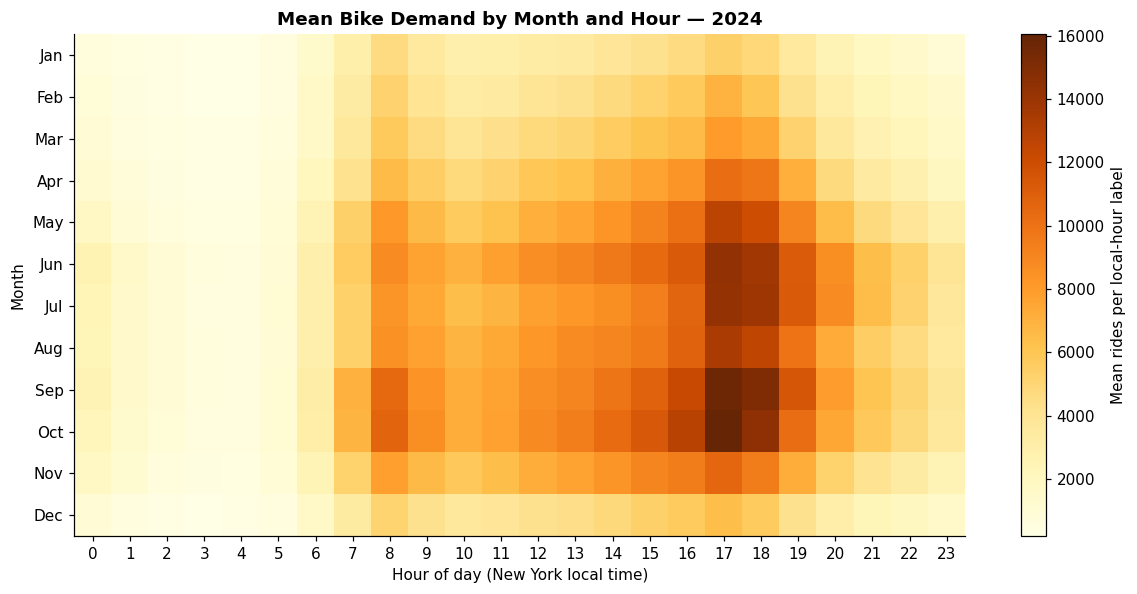

In [10]:
month_hour = df.pivot_table(index="month", columns="hour", values="ride_count", aggfunc="mean")
fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(month_hour.to_numpy(), aspect="auto", cmap="YlOrBr", origin="upper")
ax.set(title="Mean Bike Demand by Month and Hour — 2024", xlabel="Hour of day (New York local time)", ylabel="Month",
       xticks=range(24), yticks=range(12), yticklabels=[name[:3] for name in monthly.month_name])
fig.colorbar(im, ax=ax, label="Mean rides per local-hour label")
save_show(fig, "month_hour_heatmap.png")

**图后观察：**温暖月份与初秋的下午、傍晚高需求区更宽；9–10 月的 17:00 尤其突出。各月的深夜需求仍然较低。


## 7. 天气与需求（Weather vs Demand）

下面分别观察气温、体感温度、湿度、风速、降水、降雪和天气代码。图表展示的是**每小时需求与天气的描述性关联**，不能直接解释为天气造成了多少需求变化，因为季节、白天长度和出行时段也在变化。分箱（binning）图同时显示每组样本小时数：极端天气样本少时，均值更容易波动。

气温、湿度、风速与 `weather_code` 是各自时间戳处的状态；`precipitation_during_hour`、`rain_during_hour` 和 `snowfall_during_hour` 则使用上文解释的骑行小时区间累计值。


In [11]:
def binned_demand(column, width):
    values = df[column]
    lower = np.floor(values.min() / width) * width
    upper = np.ceil(values.max() / width) * width + width
    edges = np.arange(lower, upper + width / 10, width)
    intervals = pd.cut(values, edges, right=False, include_lowest=True)
    table = df.groupby(intervals, observed=True).ride_count.agg(mean_rides="mean", median_rides="median", samples="size").reset_index()
    table["midpoint"] = table[column].map(lambda interval: interval.mid).astype(float)
    return table

def plot_binned(table, column, x_label, filename, title, color=BLUE):
    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, height_ratios=[3, 1])
    supported = table.samples.ge(20)
    axes[0].plot(table.loc[supported, "midpoint"], table.loc[supported, "mean_rides"],
                 color=color, marker="o", linewidth=2, label="n ≥ 20")
    if (~supported).any():
        axes[0].scatter(table.loc[~supported, "midpoint"], table.loc[~supported, "mean_rides"],
                        color=DARK, marker="x", s=45, label="n < 20")
        axes[0].legend(frameon=False)
    axes[0].set(title=title, ylabel="Mean rides per local-hour label")
    axes[0].grid(axis="y", alpha=.22)
    axes[1].bar(table.midpoint, table.samples, width=(table.midpoint.iloc[1]-table.midpoint.iloc[0])*.8 if len(table)>1 else 1, color="#B5C7D6")
    axes[1].set(xlabel=x_label, ylabel="Hours")
    save_show(fig, filename)

### 气温（Temperature）

先画出每个小时的 `temperature_2m` 与 `ride_count`，再按 5°C 分箱计算平均需求。密度图能看到重叠观测在哪里集中；分箱图同时给出每组有多少小时，避免把少量极端温度当成稳定规律。


,temperature_2m,mean_rides,median_rides,samples,midpoint
0,"[-20.0, -15.0)",923.000000,923.0,1,-17.5
1,"[-15.0, -10.0)",1036.555556,818.5,18,-12.5
2,"[-10.0, -5.0)",1298.159091,822.5,220,-7.5
3,"[-5.0, 0.0)",2208.077403,1688.0,801,-2.5
4,"[0.0, 5.0)",2889.346154,2462.0,1326,2.5
5,"[5.0, 10.0)",3730.874126,3412.5,1430,7.5
6,"[10.0, 15.0)",5010.036526,4721.0,1232,12.5
7,"[15.0, 20.0)",5613.316227,5252.5,1442,17.5
8,"[20.0, 25.0)",7171.699457,7059.5,1474,22.5
9,"[25.0, 30.0)",9892.846264,9673.5,696,27.5


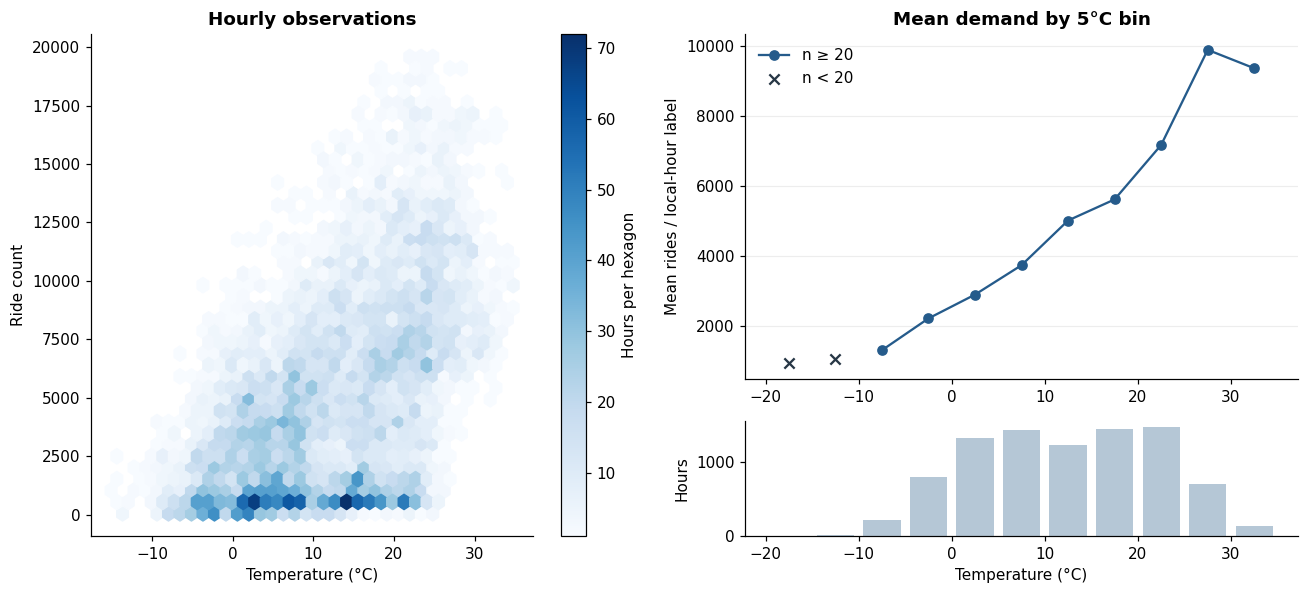

In [12]:
temperature_bins = binned_demand("temperature_2m", 5)
display(temperature_bins)
fig = plt.figure(figsize=(12, 5.5))
grid = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[3, 1])
ax_hex = fig.add_subplot(grid[:, 0])
ax_mean = fig.add_subplot(grid[0, 1])
ax_count = fig.add_subplot(grid[1, 1], sharex=ax_mean)
hb = ax_hex.hexbin(df.temperature_2m, df.ride_count, gridsize=35, cmap="Blues", mincnt=1)
ax_hex.set(title="Hourly observations", xlabel="Temperature (°C)", ylabel="Ride count")
fig.colorbar(hb, ax=ax_hex, label="Hours per hexagon")
supported = temperature_bins.samples.ge(20)
ax_mean.plot(temperature_bins.loc[supported, "midpoint"], temperature_bins.loc[supported, "mean_rides"],
             marker="o", color=BLUE, label="n ≥ 20")
ax_mean.scatter(temperature_bins.loc[~supported, "midpoint"], temperature_bins.loc[~supported, "mean_rides"],
                color=DARK, marker="x", s=45, label="n < 20")
ax_mean.set(title="Mean demand by 5°C bin", ylabel="Mean rides / local-hour label")
ax_mean.legend(frameon=False)
ax_mean.grid(axis="y", alpha=.22)
ax_count.bar(temperature_bins.midpoint, temperature_bins.samples, width=4, color="#B5C7D6")
ax_count.set(xlabel="Temperature (°C)", ylabel="Hours")
save_show(fig, "temperature_demand.png")

**图后观察：**20–25°C 组在 1,474 小时内平均有 7,172 次骑行；25–30°C 组在 696 小时内平均有 9,893 次。30–35°C 组略低，但只有 143 小时；最冷组仅有 1 小时。季节与白天长度也可能参与形成这种关系。


### 体感温度（Apparent Temperature）

`apparent_temperature` 是考虑风寒等舒适度因素后的温度指标。沿用 5°C 分箱，便于与实测气温比较；两种温度本身也高度相关，因此要谨慎解释哪一个“更有用”。


,apparent_temperature,mean_rides,median_rides,samples,midpoint
0,"[-20.0, -15.0)",1336.346154,1078.0,26,-17.5
1,"[-15.0, -10.0)",1371.798165,971.5,218,-12.5
2,"[-10.0, -5.0)",2159.811613,1586.0,775,-7.5
3,"[-5.0, 0.0)",3019.826606,2700.0,1090,-2.5
4,"[0.0, 5.0)",3539.713689,3171.5,1198,2.5
5,"[5.0, 10.0)",4742.061076,4385.0,1097,7.5
6,"[10.0, 15.0)",5189.156762,4602.5,976,12.5
7,"[15.0, 20.0)",6150.476510,5918.0,1192,17.5
8,"[20.0, 25.0)",7528.369403,7415.0,1072,22.5
9,"[25.0, 30.0)",7569.303970,7600.5,806,27.5


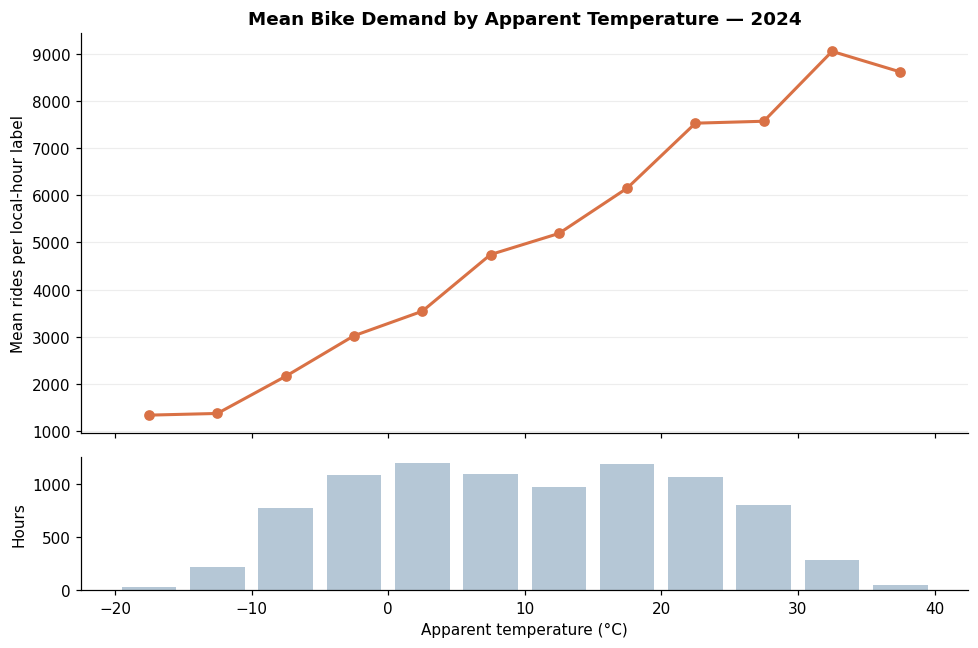

,correlation
Temperature vs demand (Pearson r),0.539317
Apparent temperature vs demand (Pearson r),0.487006
Temperature vs apparent temperature (Pearson r),0.990559


In [13]:
apparent_bins = binned_demand("apparent_temperature", 5)
display(apparent_bins)
plot_binned(apparent_bins, "apparent_temperature", "Apparent temperature (°C)",
            "apparent_temperature_demand.png", "Mean Bike Demand by Apparent Temperature — 2024", ORANGE)
temperature_comparison = pd.Series({
    "Temperature vs demand (Pearson r)": df[["temperature_2m", "ride_count"]].corr().iloc[0,1],
    "Apparent temperature vs demand (Pearson r)": df[["apparent_temperature", "ride_count"]].corr().iloc[0,1],
    "Temperature vs apparent temperature (Pearson r)": df[["temperature_2m", "apparent_temperature"]].corr().iloc[0,1],
})
display(temperature_comparison.to_frame("correlation"))

**图后观察：**体感温度的分箱曲线也总体随温度上升。实测与体感温度的相关系数为 0.991；它们与需求的相关系数分别为 0.539 和 0.487。这些数值没有控制小时和季节，不能单独判定哪一种温度更能解释需求。


### 相对湿度（Relative Humidity）

`relative_humidity_2m` 表示相对湿度。按每 10 个百分点分箱，是为了看需求是否随湿度稳定变化，还是受到季节、降雨与气温共同影响。


,relative_humidity_2m,mean_rides,median_rides,samples,midpoint
0,"[10.0, 20.0)",11168.500000,11299.0,6,15.0
1,"[20.0, 30.0)",9464.315789,10471.0,95,25.0
2,"[30.0, 40.0)",9143.406463,8913.0,588,35.0
3,"[40.0, 50.0)",7415.725714,7070.5,1050,45.0
4,"[50.0, 60.0)",5945.935663,5773.0,1259,55.0
5,"[60.0, 70.0)",5367.016620,5094.5,1444,65.0
6,"[70.0, 80.0)",4523.600746,3746.5,1340,75.0
7,"[80.0, 90.0)",3666.004255,2788.5,1410,85.0
8,"[90.0, 100.0)",2326.546044,1415.0,1542,95.0
9,"[100.0, 110.0)",2443.122449,1272.0,49,105.0


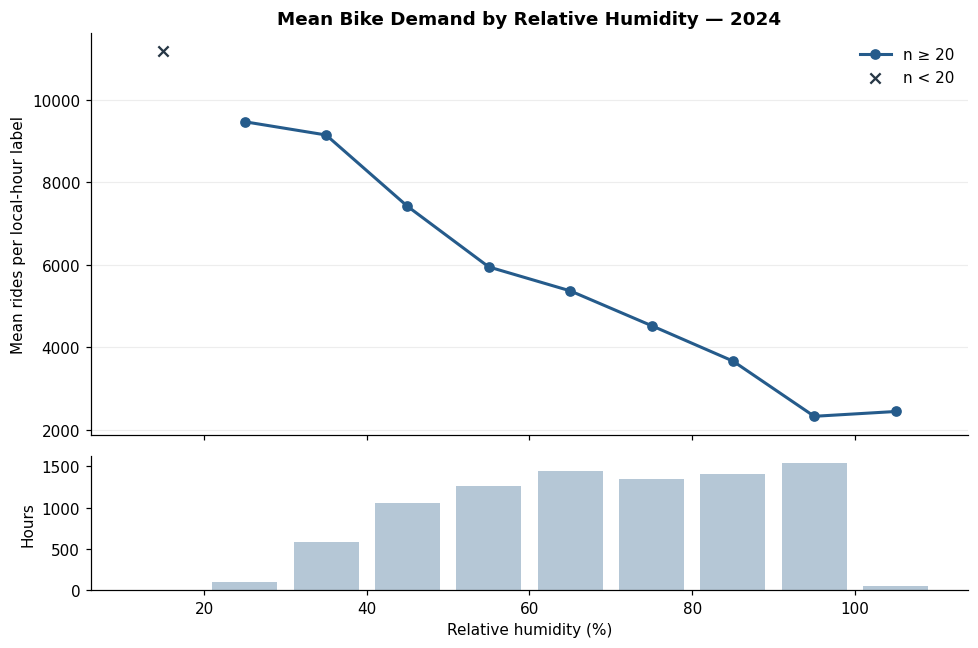

In [14]:
humidity_bins = binned_demand("relative_humidity_2m", 10)
display(humidity_bins)
plot_binned(humidity_bins, "relative_humidity_2m", "Relative humidity (%)", "humidity_demand.png",
            "Mean Bike Demand by Relative Humidity — 2024")

**图后观察：**30–40% 湿度组的平均需求为 9,143 次（588 小时），而 90–100% 组为 2,327 次（1,542 小时）。10–20% 组只有 6 小时。湿度、雨、气温和季节相互交织，不能把组间差异直接归因于湿度。


### 风速（Wind Speed）

`wind_speed_10m` 是 10 米高度处的风速。按每 5 km/h 分箱并保留样本小时数，特别是为了检查大风区间是否因观测太少而出现不稳定的均值。


,wind_speed_10m,mean_rides,median_rides,samples,midpoint
0,"[0.0, 5.0)",4210.764115,3386.0,797,2.5
1,"[5.0, 10.0)",4443.402144,3582.0,2892,7.5
2,"[10.0, 15.0)",5280.661271,4518.0,2533,12.5
3,"[15.0, 20.0)",5948.750000,5440.5,1536,17.5
4,"[20.0, 25.0)",5661.989552,4943.5,670,22.5
5,"[25.0, 30.0)",5123.808333,4449.0,240,27.5
6,"[30.0, 35.0)",5475.074074,5247.0,81,32.5
7,"[35.0, 40.0)",3924.200000,2664.0,20,37.5
8,"[40.0, 45.0)",3470.100000,1984.0,10,42.5
9,"[45.0, 50.0)",1045.333333,295.0,3,47.5


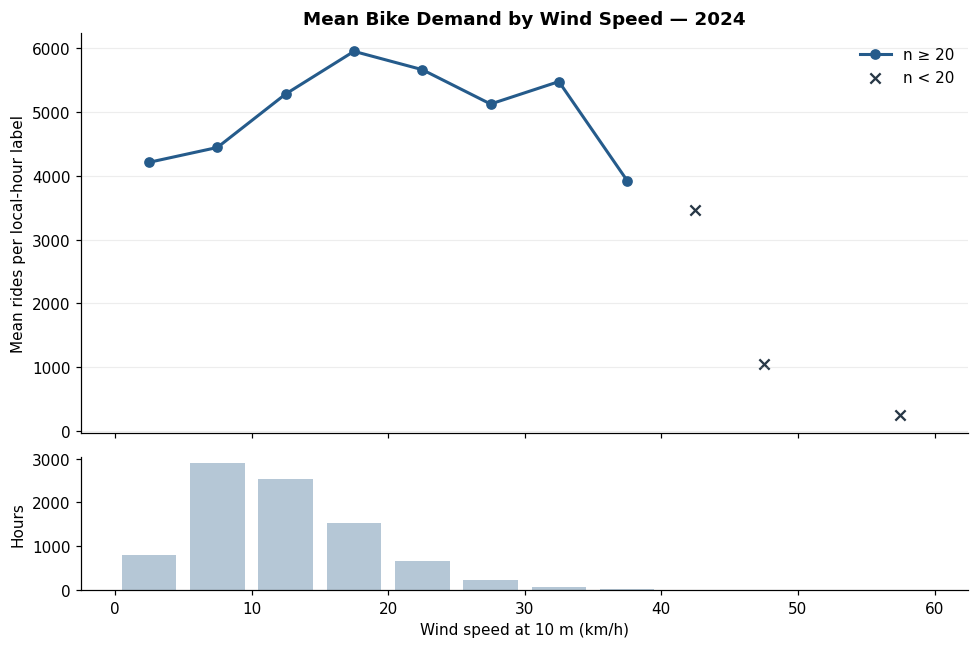

In [15]:
wind_bins = binned_demand("wind_speed_10m", 5)
display(wind_bins)
plot_binned(wind_bins, "wind_speed_10m", "Wind speed at 10 m (km/h)", "wind_demand.png",
            "Mean Bike Demand by Wind Speed — 2024")

**图后观察：**平均需求从 0–5 km/h 组的 4,211 次升至 15–20 km/h 组的 5,949 次，之后若干更强风组较低。35 km/h 及以上的组样本很少，末端曲线不稳定；简单线性相关仅为 0.114。


### 降水与降雨（Precipitation and Rain）

这里使用按骑行小时对齐的 `precipitation_during_hour` 和 `rain_during_hour`，而不是原始时间戳处的累计列。分组定义如下：

- **无雨（No rain）：**`rain_during_hour == 0`，其中仍可能有只下雪的小时。
- **小雨（Light rain）：**`rain_during_hour > 0`，且这个骑行小时的总降水小于 1.0 mm。
- **中等及以上（Moderate+）：**`rain_during_hour > 0`，且这个骑行小时的总降水至少为 1.0 mm。

1 mm/h 只是本次 EDA 的描述性分界，并非官方气象强度等级。旁边的二分类图单独比较 `rain_during_hour > 0` 与 `== 0`，用于观察“是否下雨”的整体差异。


,mean_rides,median_rides,samples
precipitation_category,,,
No rain,5265.089130,4540.0,7562
Light rain,3945.302142,3137.0,887
Moderate+,2960.215569,1608.0,334


,mean_rides,median_rides,samples
rain_present,,,
No rain,5265.089130,4540.0,7562
Rain > 0,3675.835381,2642.0,1221


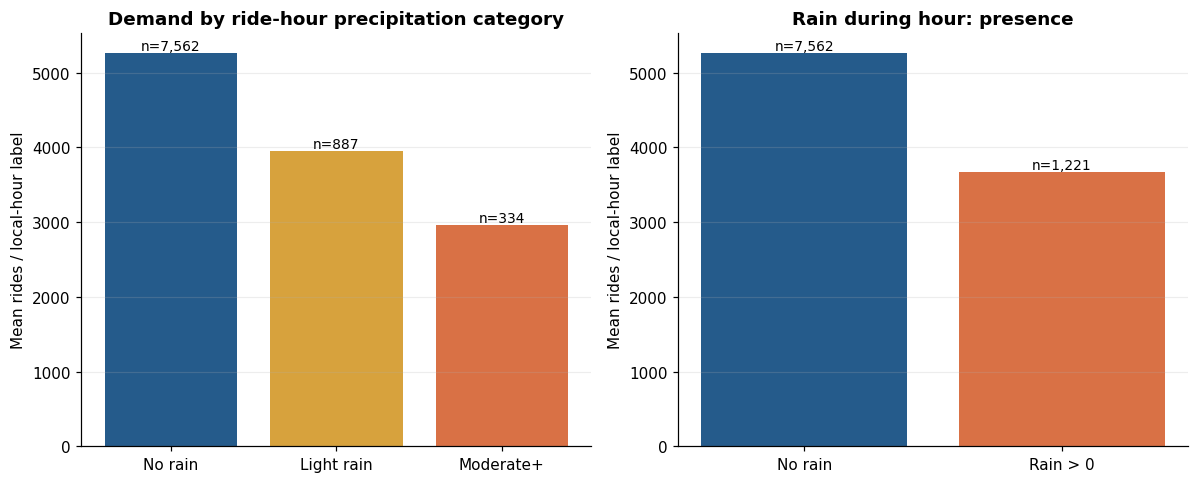

In [16]:
rain = df.rain_during_hour
precip = df.precipitation_during_hour
df["precipitation_category"] = np.select(
    [rain.eq(0), rain.gt(0) & precip.lt(1), rain.gt(0) & precip.ge(1)],
    ["No rain", "Light rain", "Moderate+"], default="Unclassified"
)
assert not df.precipitation_category.eq("Unclassified").any()
category_order = ["No rain", "Light rain", "Moderate+"]
precip_stats = df.groupby("precipitation_category").ride_count.agg(mean_rides="mean", median_rides="median", samples="size").reindex(category_order)
rain_presence = df.assign(rain_present=rain.gt(0)).groupby("rain_present").ride_count.agg(mean_rides="mean", median_rides="median", samples="size")
rain_presence.index = rain_presence.index.map({False: "No rain", True: "Rain > 0"})
display(precip_stats)
display(rain_presence)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(category_order, precip_stats.mean_rides, color=[BLUE, GOLD, ORANGE])
axes[0].set(title="Demand by ride-hour precipitation category", ylabel="Mean rides / local-hour label")
for i, n in enumerate(precip_stats.samples): axes[0].text(i, precip_stats.mean_rides.iloc[i], f"n={n:,}", ha="center", va="bottom", fontsize=9)
axes[1].bar(rain_presence.index, rain_presence.mean_rides, color=[BLUE, ORANGE])
axes[1].set(title="Rain during hour: presence", ylabel="Mean rides / local-hour label")
for i, n in enumerate(rain_presence.samples): axes[1].text(i, rain_presence.mean_rides.iloc[i], f"n={n:,}", ha="center", va="bottom", fontsize=9)
for ax in axes: ax.grid(axis="y", alpha=.22)
save_show(fig, "precipitation_demand.png")

**图后观察：**无雨小时平均 5,265 次（n=7,562），小雨小时 3,945 次（n=887），中等及以上组 2,960 次（n=334）。所有有雨小时平均 3,676 次（n=1,221），比无雨小时约低 30%。无雨组包括只下雪的小时；这只是描述性比较，不能视为降雨的因果效应。


### 降雪（Snowfall）

`snowfall_during_hour` 的单位是 **cm**，表示骑行小时内的累计降雪。先看有雪与无雪各有多少小时，再比较平均需求；如果雪天很少，差异容易受季节和个别日期影响。


,mean_rides,median_rides,samples
snow_present,,,
No snow,5091.532495,4294.0,8663
Snow > 0 cm,1623.775000,1188.5,120


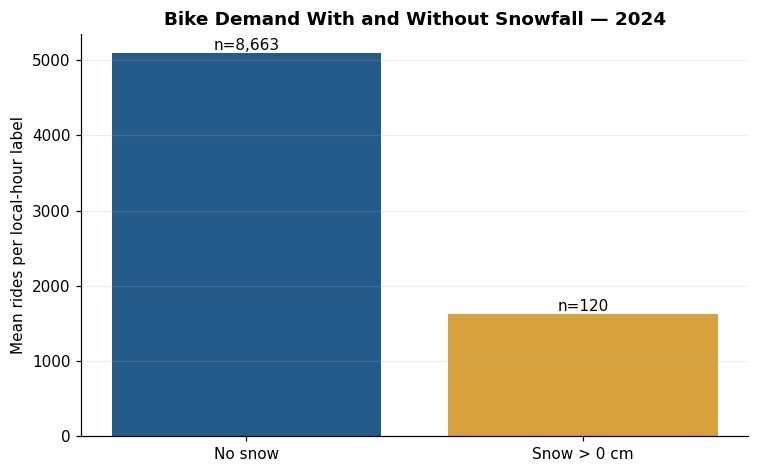

In [17]:
snow_stats = df.assign(snow_present=df.snowfall_during_hour.gt(0)).groupby("snow_present").ride_count.agg(mean_rides="mean", median_rides="median", samples="size")
snow_stats.index = snow_stats.index.map({False: "No snow", True: "Snow > 0 cm"})
display(snow_stats)
fig, ax = plt.subplots(figsize=(7, 4.4))
ax.bar(snow_stats.index, snow_stats.mean_rides, color=[BLUE, GOLD])
ax.set(title="Bike Demand With and Without Snowfall — 2024", ylabel="Mean rides per local-hour label")
for i, n in enumerate(snow_stats.samples): ax.text(i, snow_stats.mean_rides.iloc[i], f"n={n:,}", ha="center", va="bottom")
ax.grid(axis="y", alpha=.22)
save_show(fig, "snowfall_demand.png")

**图后观察：**仅有 120 个小时出现正降雪，平均每标签 1,624 次；8,663 个无雪小时平均 5,092 次。雪天样本小且集中于冬季，不能把差异单独解释为降雪造成的变化。


### 天气代码（WMO Weather Code）

`weather_code` 表示时间戳处的天气状态（instantaneous state），与“前一小时累计降水”口径不同。这里依据 [Open-Meteo 的 WMO 对照表](https://open-meteo.com/en/docs/historical-weather-api)归组：晴（Clear）= 0；多云（Cloudy）= 1–3；雨（Rain）包括毛毛雨 51/53/55/56/57、降雨 61/63/65/66/67 和阵雨 80/81/82；雪（Snow）= 71/73/75/77/85/86；其他（Other）包括雾 45/48、雷暴 95/96/99 和未映射代码。

秋季重复的 01:00 在源表中使用两个物理小时天气代码的 `max` 汇总，因此该标签的天气类别比普通单小时更粗略。


,hours
WMO code,
0.0,3107
1.0,841
2.0,614
3.0,2912
51.0,651
53.0,218
55.0,59
61.0,120
63.0,113


,samples,mean_rides
weather_group,,
Clear,3107,5076.508851
Cloudy,4367,5465.460041
Rain,1189,3757.778806
Snow,120,1620.191667
Other,0,NaN


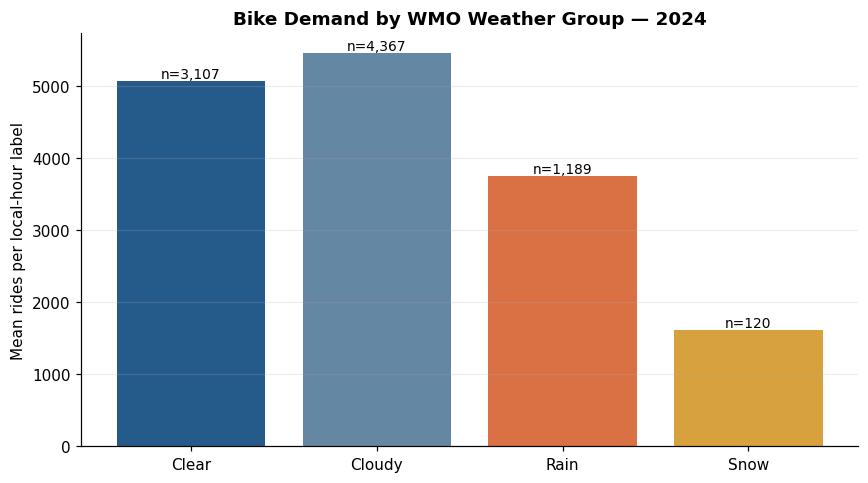

In [18]:
RAIN_CODES = {51, 53, 55, 56, 57, 61, 63, 65, 66, 67, 80, 81, 82}
SNOW_CODES = {71, 73, 75, 77, 85, 86}
def weather_group(code):
    code = int(code)
    if code == 0: return "Clear"
    if code in {1, 2, 3}: return "Cloudy"
    if code in RAIN_CODES: return "Rain"
    if code in SNOW_CODES: return "Snow"
    return "Other"

df["weather_group"] = df.weather_code.map(weather_group)
weather_code_stats = df.groupby("weather_group").ride_count.agg(samples="size", mean_rides="mean").reindex(["Clear", "Cloudy", "Rain", "Snow", "Other"])
weather_code_stats["samples"] = weather_code_stats.samples.fillna(0).astype(int)
weather_codes_observed = df.weather_code.value_counts().sort_index().rename_axis("WMO code").to_frame("hours")
display(weather_codes_observed)
display(weather_code_stats)
plotted_weather = weather_code_stats.loc[weather_code_stats.samples.gt(0)]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(plotted_weather.index, plotted_weather.mean_rides, color=[BLUE, "#6487A3", ORANGE, GOLD, DARK][:len(plotted_weather)])
ax.set(title="Bike Demand by WMO Weather Group — 2024", ylabel="Mean rides per local-hour label")
for i, n in enumerate(plotted_weather.samples): ax.text(i, plotted_weather.mean_rides.iloc[i], f"n={n:,}", ha="center", va="bottom", fontsize=9)
ax.grid(axis="y", alpha=.22)
save_show(fig, "weather_code_demand.png")

**图后观察：**多云组最常见，共 4,367 小时，平均需求 5,465 次。晴天组为 3,107 小时、平均 5,077 次；雨组为 1,189 小时、平均 3,758 次；雪组为 120 小时、平均 1,620 次。按当前映射，2024 年没有落入“其他”组的小时。


### 连续变量相关性（Continuous-variable Correlation）

皮尔逊相关系数（Pearson r）概括此数据粒度下的**线性关联**。系数小不等于变量没有用：关系可能不是直线，也可能受时段、季节共同影响。雨量与总降水属于相关的组成指标，不能把它们的系数当作互相独立的证据。


,ride_count,temperature_2m,apparent_temperature,relative_humidity_2m,wind_speed_10m,precipitation_during_hour,rain_during_hour,snowfall_during_hour
ride_count,1.000,0.539,0.487,-0.476,0.114,-0.088,-0.079,-0.073
temperature_2m,0.539,1.000,0.991,-0.105,0.014,0.031,0.044,-0.096
apparent_temperature,0.487,0.991,1.000,-0.011,-0.084,0.037,0.050,-0.095
relative_humidity_2m,-0.476,-0.105,-0.011,1.000,-0.253,0.198,0.191,0.063
wind_speed_10m,0.114,0.014,-0.084,-0.253,1.000,0.131,0.127,0.042
precipitation_during_hour,-0.088,0.031,0.037,0.198,0.131,1.000,0.991,0.137
rain_during_hour,-0.079,0.044,0.050,0.191,0.127,0.991,1.000,0.001
snowfall_during_hour,-0.073,-0.096,-0.095,0.063,0.042,0.137,0.001,1.000


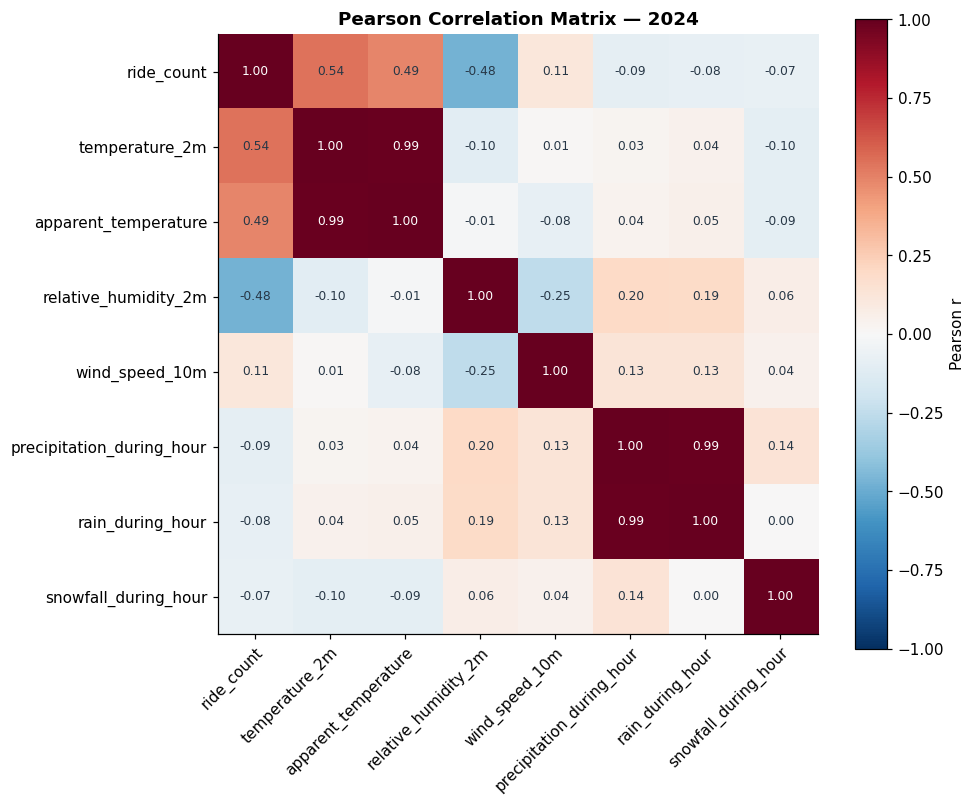

In [19]:
correlation_columns = ["ride_count", "temperature_2m", "apparent_temperature", "relative_humidity_2m",
                       "wind_speed_10m", "precipitation_during_hour", "rain_during_hour", "snowfall_during_hour"]
corr = df[correlation_columns].corr()
display(corr.round(3))
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
ax.set(title="Pearson Correlation Matrix — 2024", xticks=range(len(corr)), yticks=range(len(corr)),
       xticklabels=corr.columns, yticklabels=corr.index)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(len(corr)):
    for j in range(len(corr)):
        value = corr.iat[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if abs(value) > .55 else DARK, fontsize=8)
fig.colorbar(im, ax=ax, label="Pearson r")
save_show(fig, "correlation_matrix.png")

**图后观察：**需求与气温呈正相关（0.539），与湿度呈负相关（−0.476）。对齐后的总降水、雨量和降雪的系数绝对值较小（分别为 −0.088、−0.079、−0.073）。解释这些结果时，还要结合分箱图及小时、季节背景。


## 8. 需求分布与异常值检查（Distribution and Anomalies）

四分位距（IQR）的 1.5 倍上界只用于**筛查**，不是删除规则。高需求可能是真实的季节性或通勤高峰，因此还要看日期、小时、天气，以及它比同月同小时平均值高多少。节假日和活动需要额外证据，本 Notebook 不直接把它们写成原因。秋季合并的双小时标签另有 `dst_fallback_anomaly` 标记。


IQR fences: low < 0.0, high > 17,186.5 rides
High flags: 54; low flags: 0; zero-ride real hours: 0
Largest hours with local context:


,timestamp,day_name,ride_count,month_hour_mean,vs_month_hour_mean,precipitation_during_hour,high_demand_iqr_flag,dst_fallback_anomaly
7096,2024-10-22 17:00:00,Tuesday,19579,16044.387097,1.220302,0.0,True,False
6088,2024-09-10 17:00:00,Tuesday,19545,15697.233333,1.245124,0.0,True,False
6256,2024-09-17 17:00:00,Tuesday,19544,15697.233333,1.245060,0.0,True,False
6280,2024-09-18 17:00:00,Wednesday,19434,15697.233333,1.238053,0.0,True,False
7120,2024-10-23 17:00:00,Wednesday,19412,16044.387097,1.209894,0.0,True,False
6304,2024-09-19 17:00:00,Thursday,19364,15697.233333,1.233593,0.0,True,False
6136,2024-09-12 17:00:00,Thursday,19285,15697.233333,1.228560,0.0,True,False
6112,2024-09-11 17:00:00,Wednesday,19257,15697.233333,1.226777,0.0,True,False
6424,2024-09-24 17:00:00,Tuesday,19088,15697.233333,1.216010,0.0,True,False
7288,2024-10-30 17:00:00,Wednesday,19028,16044.387097,1.185960,0.0,True,False


Smallest real hours with local context:


,timestamp,day_name,ride_count,month_hour_mean,vs_month_hour_mean,precipitation_during_hour,low_demand_iqr_flag,dst_fallback_anomaly
1035,2024-02-13 03:00:00,Tuesday,50,207.620690,0.240824,2.1,False,False
363,2024-01-16 03:00:00,Tuesday,52,190.741935,0.272620,0.3,False,False
411,2024-01-18 03:00:00,Thursday,61,190.741935,0.319804,0.0,False,False
2258,2024-04-04 03:00:00,Thursday,62,317.900000,0.195030,1.2,False,False
387,2024-01-17 03:00:00,Wednesday,66,190.741935,0.346017,0.0,False,False
2089,2024-03-28 02:00:00,Thursday,67,401.133333,0.167027,1.0,False,False
1036,2024-02-13 04:00:00,Tuesday,75,217.689655,0.344527,1.9,False,False
149,2024-01-07 05:00:00,Sunday,78,521.451613,0.149582,0.1,False,False
8738,2024-12-30 03:00:00,Monday,80,248.935484,0.321368,0.1,False,False
675,2024-01-29 03:00:00,Monday,84,190.741935,0.440386,0.1,False,False


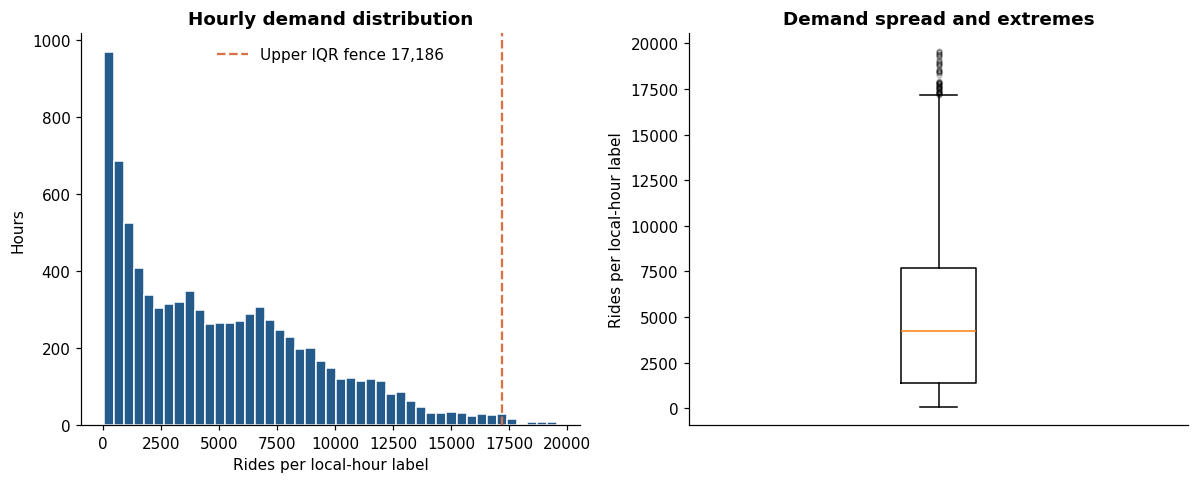

In [20]:
q1, q3 = df.ride_count.quantile([.25, .75])
iqr = q3 - q1
lower_fence = max(0, q1 - 1.5 * iqr)
upper_fence = q3 + 1.5 * iqr
df["high_demand_iqr_flag"] = df.ride_count.gt(upper_fence)
df["low_demand_iqr_flag"] = df.ride_count.lt(lower_fence)
df["month_hour_mean"] = df.set_index(["month", "hour"]).index.map(month_hour.stack()).to_numpy()
df["vs_month_hour_mean"] = df.ride_count / df.month_hour_mean
print(f"IQR fences: low < {lower_fence:,.1f}, high > {upper_fence:,.1f} rides")
print(f"High flags: {df.high_demand_iqr_flag.sum():,}; low flags: {df.low_demand_iqr_flag.sum():,}; "
      f"zero-ride real hours: {df.ride_count.eq(0).sum():,}")
print("Largest hours with local context:")
display(df.nlargest(10, "ride_count")[["timestamp", "day_name", "ride_count", "month_hour_mean", "vs_month_hour_mean",
                                         "precipitation_during_hour", "high_demand_iqr_flag", "dst_fallback_anomaly"]])
print("Smallest real hours with local context:")
display(df.nsmallest(10, "ride_count")[["timestamp", "day_name", "ride_count", "month_hour_mean", "vs_month_hour_mean",
                                          "precipitation_during_hour", "low_demand_iqr_flag", "dst_fallback_anomaly"]])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(df.ride_count, bins=45, color=BLUE, edgecolor="white")
axes[0].axvline(upper_fence, color=ORANGE, linestyle="--", label=f"Upper IQR fence {upper_fence:,.0f}")
axes[0].set(title="Hourly demand distribution", xlabel="Rides per local-hour label", ylabel="Hours")
axes[0].legend(frameon=False)
axes[1].boxplot(df.ride_count, vert=True, showfliers=True, flierprops={"marker": ".", "alpha": .25})
axes[1].set(title="Demand spread and extremes", ylabel="Rides per local-hour label", xticks=[])
save_show(fig, "demand_distribution.png")

**图后观察：**IQR 上界为 17,186.5 次，共标记 54 个高需求小时。最高的十个标签都位于 9–10 月工作日的 17:00，约为对应同月同小时均值的 1.19–1.25 倍，与观察到的晚高峰模式一致。最低的真实小时为 2024-02-13 03:00，共 50 次；没有真实的零骑行小时。秋季双小时标签单独标记；节假日或活动解释尚未验证。


## 核心发现（Key Findings）

1. **规模与粒度：**全年有 44,302,799 次骑行、8,783 个有效本地时钟小时标签。平均每标签 5,044.15 次、每本地日历日 121,045.90 次。由于秋季 01:00 标签合并了两个真实小时，按 8,784 个物理小时计算的均值为 5,043.58 次。
2. **夏令时质量：**春季不存在的 02:00 在源表中为零骑行、八个天气字段均缺失，EDA 将其排除。秋季 2024-11-03 01:00 合并了 3,534 次骑行，标记 `dst_fallback_anomaly`；其计数高于附近八个周日 01:00 的 856–2,947 次区间，但未被改写。
3. **月度变化：**10 月总量最高（5,150,717 次），1 月最低（1,887,908 次）；9 月的平均每小时需求最高（6,940.68 次）。月总量和每小时强度回答不同问题。
4. **小时模式：**总体最高的平均需求出现在 17:00（11,146.97 次），04:00 最低（395.13 次）。工作日出现 08:00 与 17:00 的明显通勤双峰，周末高峰推迟到 15:00。
5. **工作日与周末：**工作日均值为 5,206.69 次，周末为 4,634.53 次。周末深夜需求相对更高，08:00 没有相当的通勤高峰，下午需求上升更平缓。
6. **气温：**大多数 5°C 组的观察均值随气温升高；25–30°C 组为 9,892.85 次（696 小时），30–35°C 组略低，为 9,365.43 次（143 小时）。体感温度与实测气温高度相关（r=0.991）。
7. **雨雪：**对齐后的骑行小时内，1,221 个有雨小时平均 3,675.84 次，7,562 个无雨小时平均 5,265.09 次。仅 120 个小时有正降雪，平均 1,623.78 次；无雪小时平均 5,091.53 次。这些比较同时受季节和时段影响。
8. **湿度与风速：**湿度 30–40% 组平均 9,143 次，90–100% 组为 2,327 次。风速关系并非单调，在 15–20 km/h 组约为 5,949 次；强风组样本稀少。
9. **极端值：**1.5×IQR 筛查标记 54 个高需求标签；最高十个都在 9–10 月工作日 17:00，符合观察到的通勤及季节模式，不像明显计数错误。最低真实小时为 50 次，没有真实零骑行小时。活动和节假日原因尚未验证，也没有删除高需求观测。
10. **解释边界：**对齐后的总降水与雨量和需求的线性相关系数较小（−0.088、−0.079），但分组差异明显。非线性关系、时段与季节意味着不能只凭一个相关系数判断变量是否有用。
